# Bank Marketing - Exploratory Data Analysis

**Objective**: Predict whether a client will subscribe to a term deposit (`y`).

**Dataset**: UCI Bank Marketing (45,211 rows, 17 columns)

**Features**:
- Numeric (7): age, balance, day, duration, campaign, pdays, previous
- Categorical (10): job, marital, education, default, housing, loan, contact, month, poutcome, y (target)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('../data/bank-full.csv', sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 1. Data Overview

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


- default = Has credit default history?
- day = Day of month customer was contacted
- month = last contact month of year
- campaign = Number of contacts in current campaign
- pdays = number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)
- previous = Number of contacts before current campaign
- poutcome = Outcome of previous campaign

In [17]:
print('Missing values (NaN):')
print(df.isnull().sum())
print(df.select_dtypes(include=['object', 'str']).columns)
print('\n"unknown" values in categorical columns:')
for col in df.select_dtypes(include=['object', 'str']).columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f'  {col}: {count} ({count/len(df)*100:.2f}%)')

Missing values (NaN):
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='str')

"unknown" values in categorical columns:
  job: 288 (0.64%)
  education: 1857 (4.11%)
  contact: 13020 (28.80%)
  poutcome: 36959 (81.75%)


In [18]:
print('\nFeature types:')
print(f'Numeric: {df.select_dtypes(include=[np.number]).columns.tolist()}')
print(f'Categorical: {df.select_dtypes(include=["object", "str"]).columns.tolist()}')


Feature types:
Numeric: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


## 2. Target Variable Analysis

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


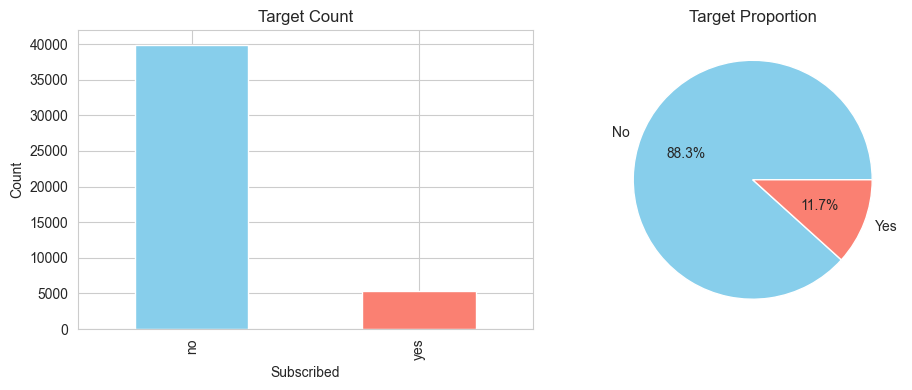

In [19]:
print('Target distribution:')
print(df['y'].value_counts())
print(f'\nPercentages:')
print(df['y'].value_counts(normalize=True).mul(100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['y'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Target Count')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Count')

df['y'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                            labels=['No', 'Yes'], colors=['skyblue', 'salmon'])
axes[1].set_title('Target Proportion')
plt.tight_layout()
plt.show()

**Finding**: Class imbalance — 88.3% no, 11.7% yes. Need stratified split and careful metric selection (F1, ROC-AUC over accuracy).

## 3. Univariate Analysis - Numeric Features

In [20]:
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
df[num_cols].describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


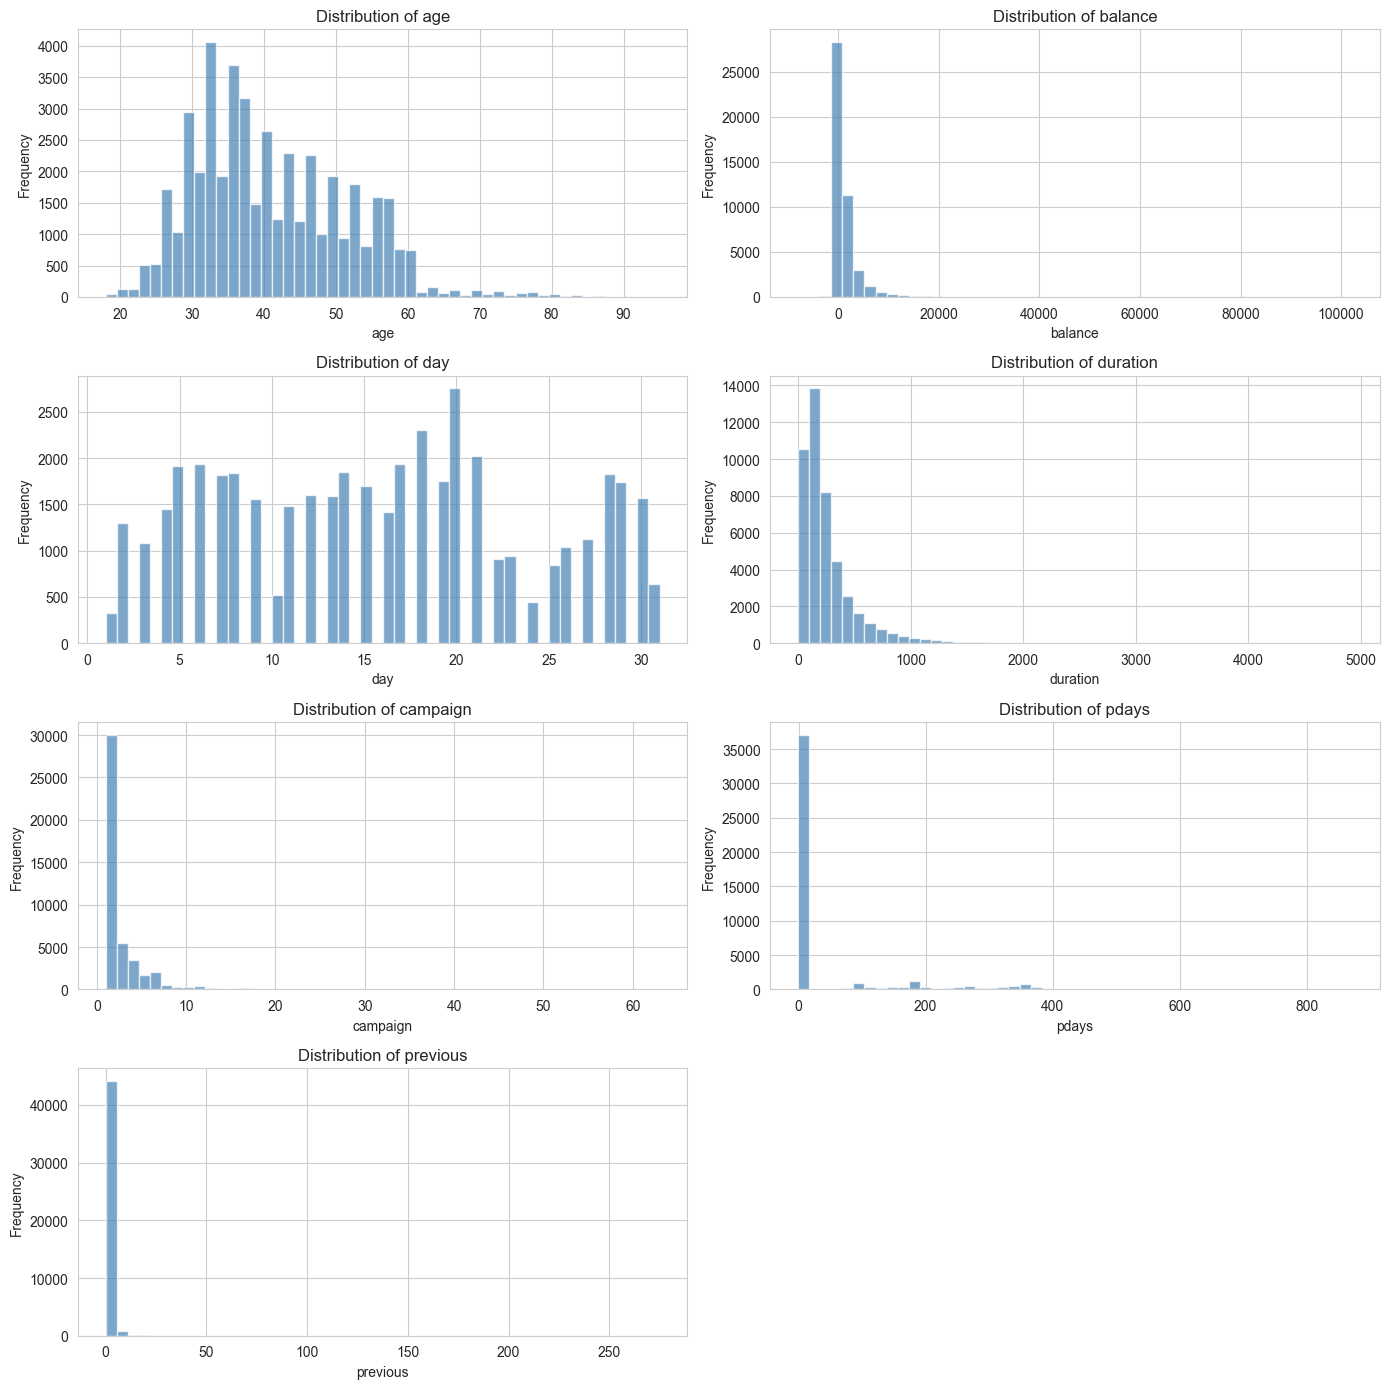

In [21]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()#deletes the unused subplot
plt.show()

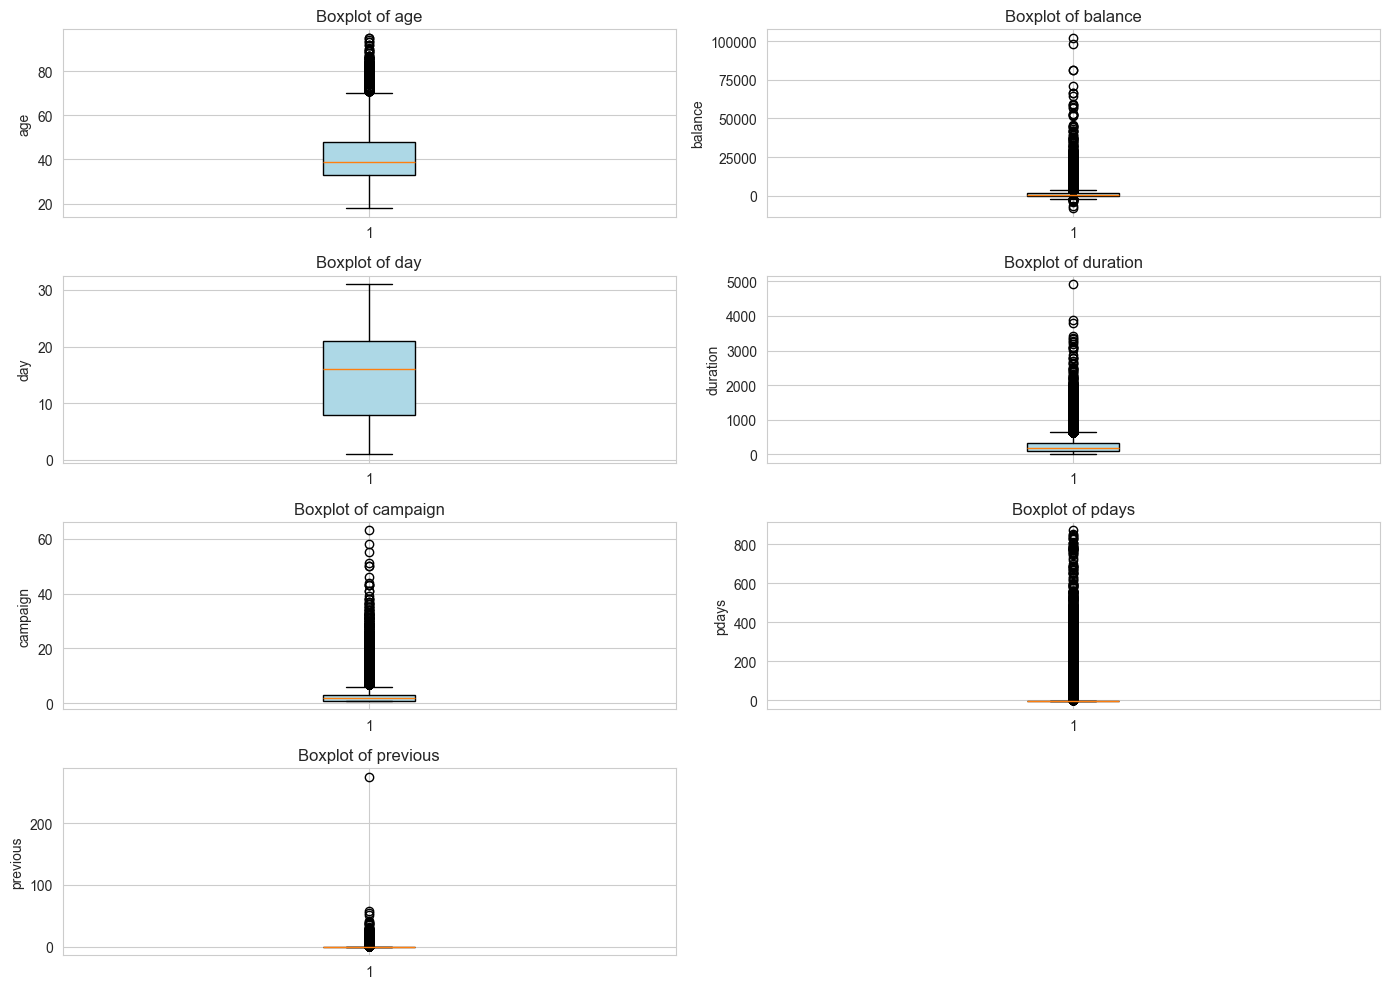

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True, 
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [23]:
# Detect outliers using IQR
print('Outlier analysis (IQR method):')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f'  {col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)')

Outlier analysis (IQR method):
  age: 487 outliers (1.08%)
  balance: 4729 outliers (10.46%)
  day: 0 outliers (0.00%)
  duration: 3235 outliers (7.16%)
  campaign: 3064 outliers (6.78%)
  pdays: 8257 outliers (18.26%)
  previous: 8257 outliers (18.26%)


**Findings**:
- `age`: roughly normal, centered ~39, some elderly outliers
- `balance`: heavily right-skewed, range -8019 to 102127
- `duration`: right-skewed, max 4918s (~82 min)
- `campaign`: right-skewed, max 63 contacts
- `pdays`: -1 is a special value (client not previously contacted)
- `previous`: mostly 0, right-skewed
- `day`: roughly uniform 1-31

## 4. Univariate Analysis - Categorical Features

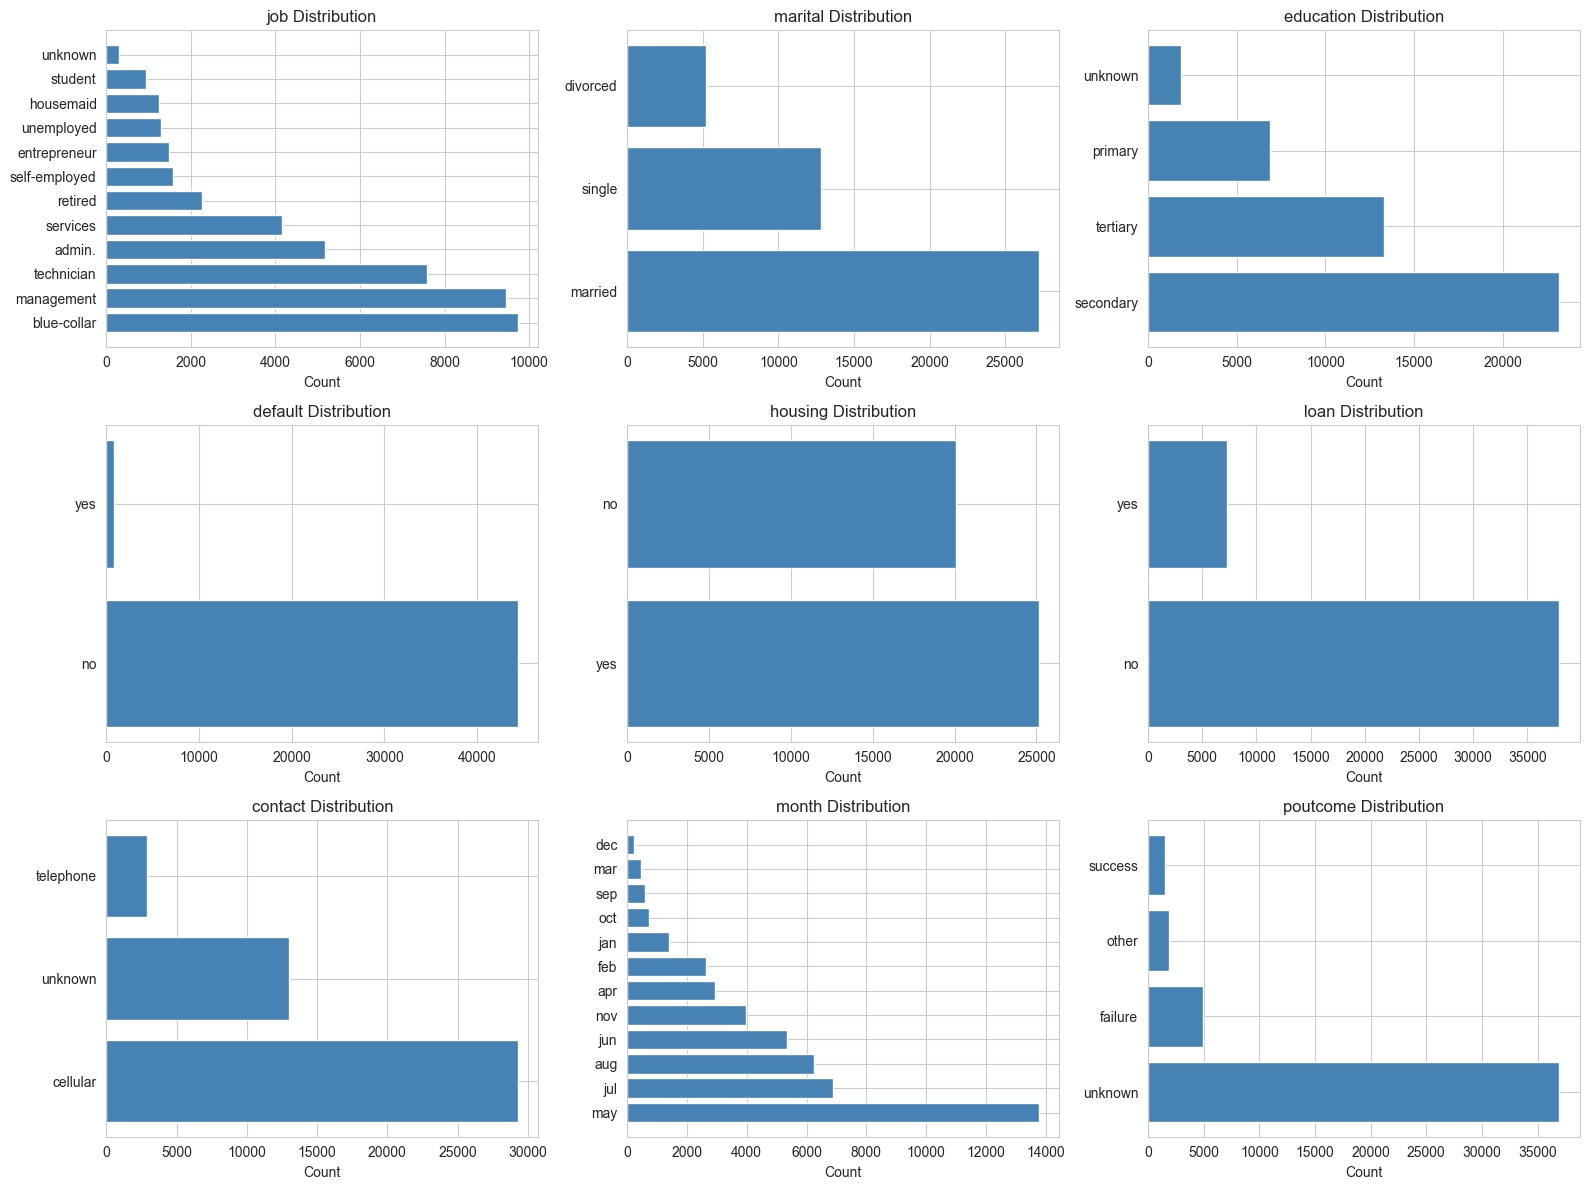

In [24]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color='steelblue')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Count')
plt.tight_layout()
plt.show()

**Findings**:
- `job`: blue-collar, management, technician most common; "unknown" is rare (0.64%)
- `marital`: married > single > divorced
- `education`: secondary most common; "unknown" is 4.11%
- `default`: only 1.8% yes — very imbalanced
- `contact`: cellular dominates; "unknown" is 28.8% — significant
- `month`: May has the most contacts; Dec/Jan/Mar least
- `poutcome`: 81.75% unknown — most clients were never contacted before

## 5. Bivariate Analysis - Target vs Numeric Features

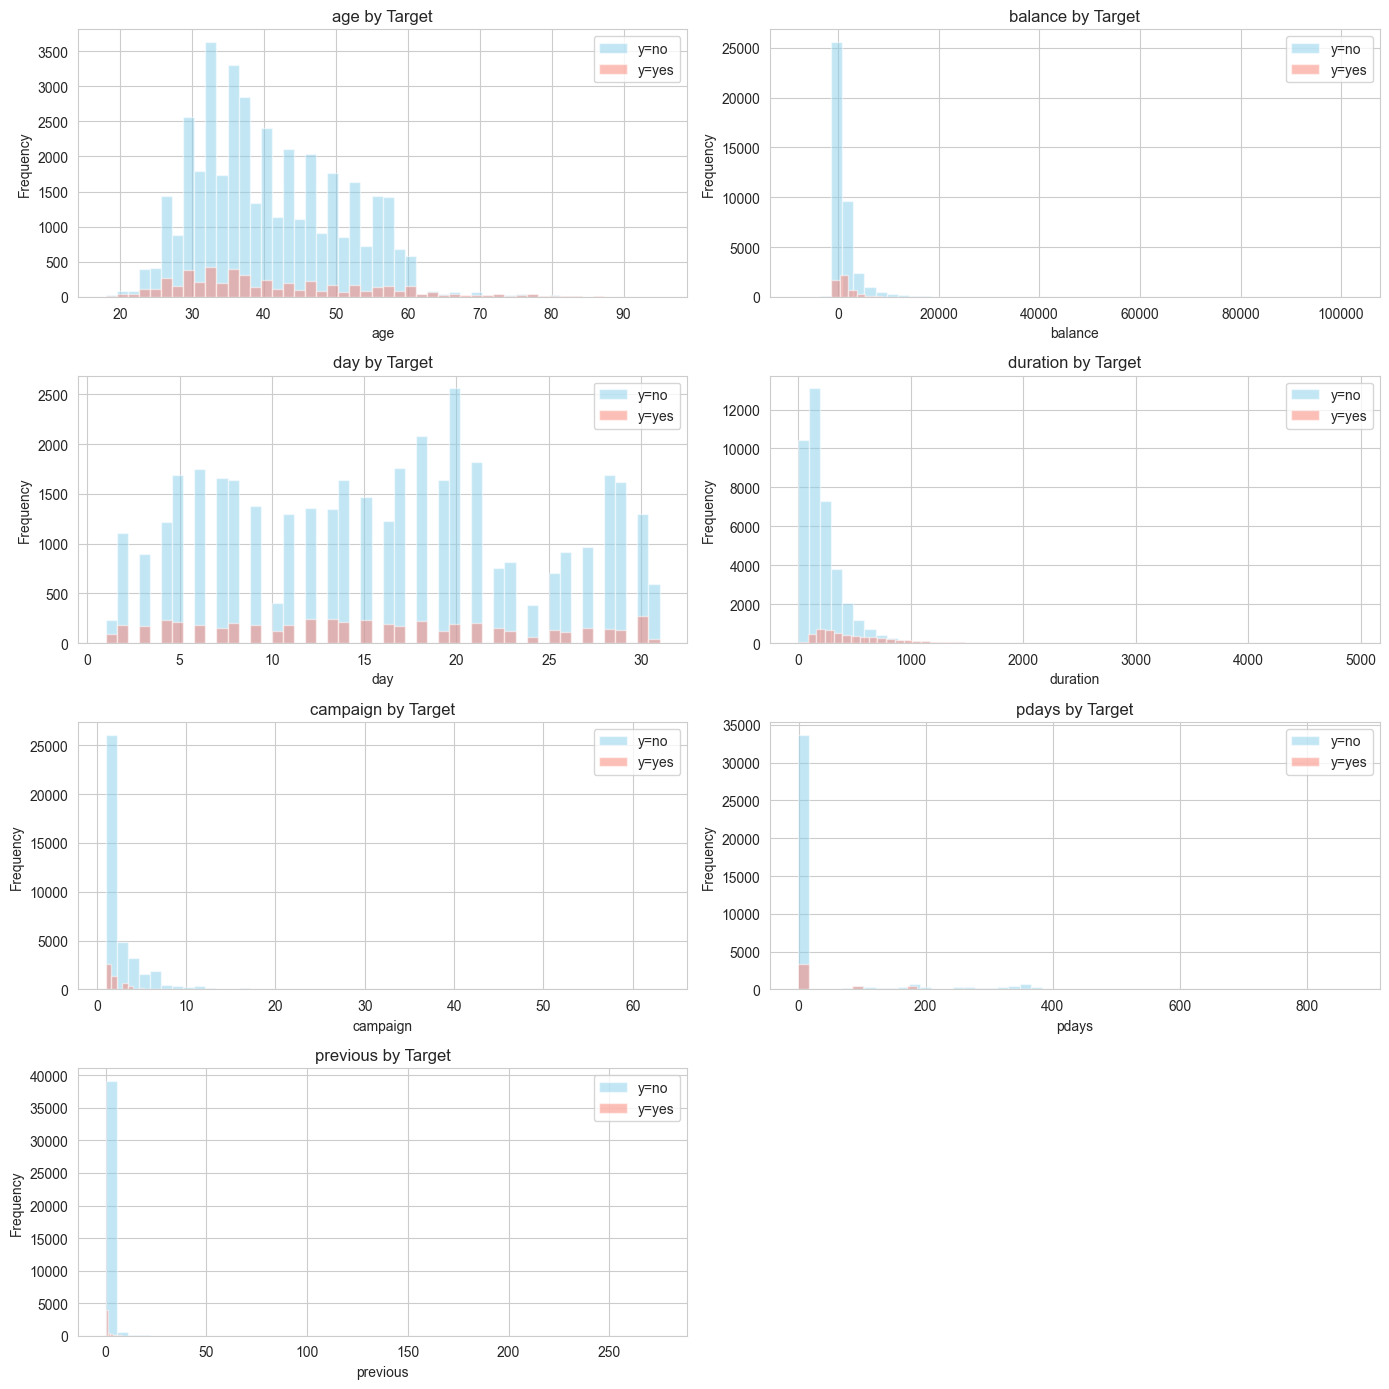

In [25]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for target_val, color in zip(['no', 'yes'], ['skyblue', 'salmon']):
        subset = df[df['y'] == target_val][col]
        axes[i].hist(subset, bins=50, alpha=0.5, label=f'y={target_val}', color=color)
    axes[i].set_title(f'{col} by Target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [26]:
print('Mean values by target:')
df.groupby('y')[num_cols].mean().round(2)

Mean values by target:


,age,balance,day,duration,campaign,pdays,previous
y,,,,,,,
no,40.84,1303.71,15.89,221.18,2.85,36.42,0.50
yes,41.67,1804.27,15.16,537.29,2.14,68.70,1.17


**Key Insights**:
- `duration`: subscribers have much higher call duration (mean 537s vs 221s)
- `pdays`: subscribers tend to have been contacted before (not -1)
- `previous`: subscribers have more previous contacts
- `campaign`: subscribers contacted fewer times in current campaign

## 6. Bivariate Analysis - Target vs Categorical Features

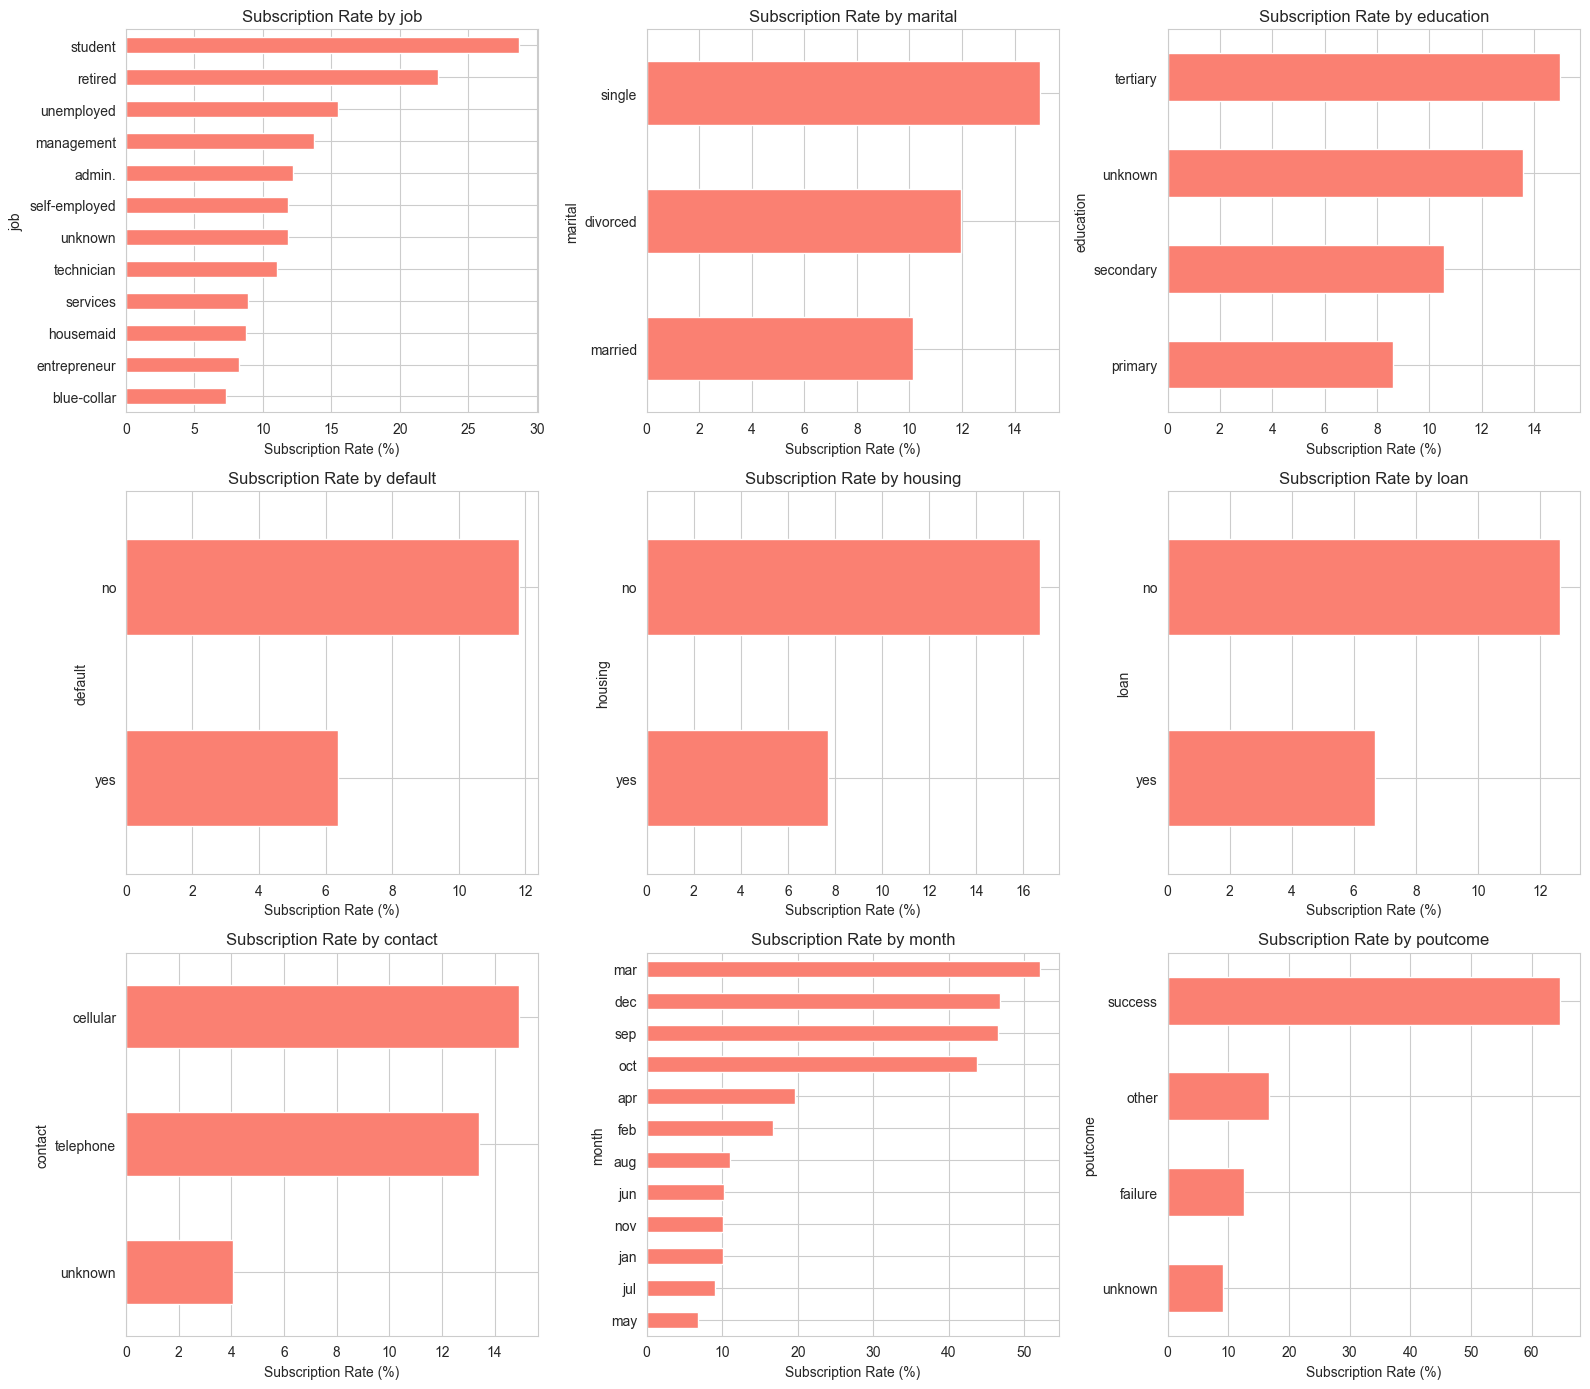

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    crosstab = pd.crosstab(df[col], df['y'], normalize='index') * 100
    crosstab['yes'].sort_values().plot(kind='barh', ax=axes[i], color='salmon')
    axes[i].set_title(f'Subscription Rate by {col}')
    axes[i].set_xlabel('Subscription Rate (%)')
plt.tight_layout()
plt.show()

In [28]:
print('Subscription rate by categorical feature:\n')
for col in cat_cols:
    print(f'\n--- {col} ---')
    ct = pd.crosstab(df[col], df['y'], normalize='index').mul(100).round(2)
    print(ct)

Subscription rate by categorical feature:


--- job ---
y                 no    yes
job                        
admin.         87.80  12.20
blue-collar    92.73   7.27
entrepreneur   91.73   8.27
housemaid      91.21   8.79
management     86.24  13.76
retired        77.21  22.79
self-employed  88.16  11.84
services       91.12   8.88
student        71.32  28.68
technician     88.94  11.06
unemployed     84.50  15.50
unknown        88.19  11.81

--- marital ---
y            no    yes
marital               
divorced  88.05  11.95
married   89.88  10.12
single    85.05  14.95

--- education ---
y             no    yes
education              
primary    91.37   8.63
secondary  89.44  10.56
tertiary   84.99  15.01
unknown    86.43  13.57

--- default ---
y           no    yes
default              
no       88.20  11.80
yes      93.62   6.38

--- housing ---
y          no   yes
housing            
no       83.3  16.7
yes      92.3   7.7

--- loan ---
y        no    yes
loan              
no 

**Key Insights**:
- `poutcome`: success → 60%+ subscription rate (highly predictive)
- `contact`: cellular ~14% vs telephone ~7%
- `month`: Mar-Dec have varying rates; May shows low rate (many contacts but few conversions)
- `education`: tertiary > secondary > primary
- `default`: default=yes clients almost never subscribe (~2%)

## 7. Correlation Analysis

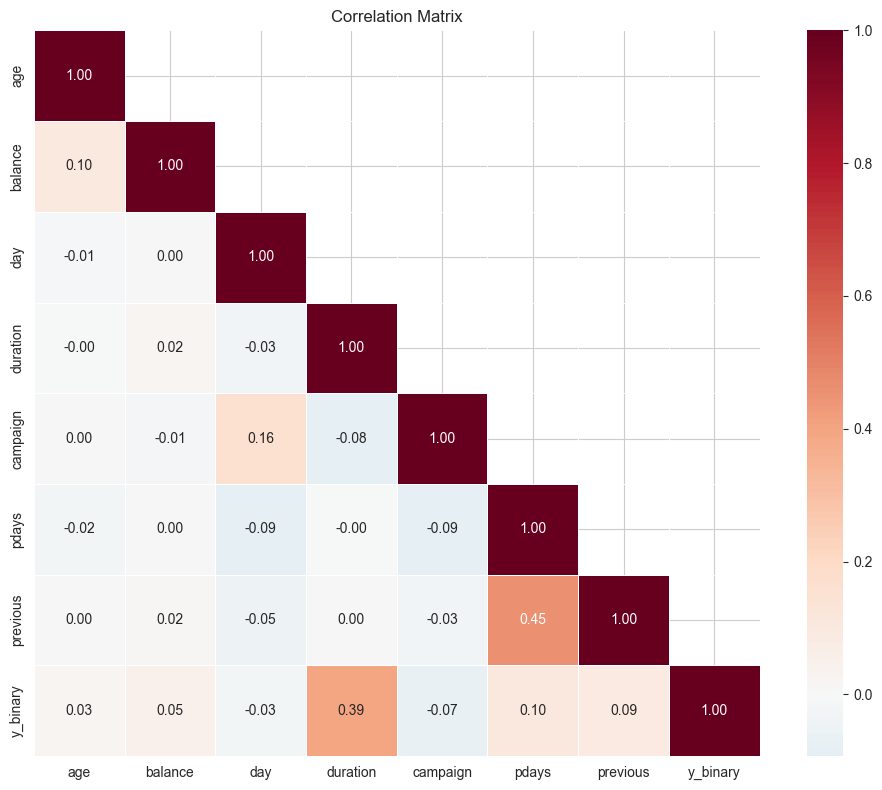

In [29]:
numeric_df = df[num_cols].copy()
numeric_df['y_binary'] = (df['y'] == 'yes').astype(int)

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [30]:
print('Top correlations with target (y_binary):')
target_corr = corr['y_binary'].drop('y_binary').sort_values(ascending=False)
print(target_corr)

Top correlations with target (y_binary):
duration    0.394521
pdays       0.103621
previous    0.093236
balance     0.052838
age         0.025155
day        -0.028348
campaign   -0.073172
Name: y_binary, dtype: float64


**Findings**:
- `duration` has strongest correlation with target (0.40)
- `pdays` (0.11) and `previous` (0.10) show moderate correlation
- Most numeric features have weak linear correlation with target
- Non-linear relationships may exist — tree-based models may perform well

## 8. Summary & Preprocessing Decisions

In [31]:
print('=== EDA Summary ===')
print(f'\nDataset: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Target: Binary classification (88.3% no vs 11.7% yes)')
print(f'\nPreprocessing decisions:')
print(f'1. Missing values: No NaN values found; "unknown" treated as a category')
print(f'2. Scaling: StandardScaler for numeric features (skewed distributions)')
print(f'3. Encoding: OneHotEncoder for categorical features (< 15 categories)')
print(f'4. Outliers: Will compare with/without clipping for tree vs linear models')
print(f'5. Special values: pdays=-1 indicates no previous contact — preserve as-is')
print(f'6. Class imbalance: Use class_weight or SMOTE; evaluate with F1/ROC-AUC')
print(f'7. duration feature: Highly correlated with target but may cause data leakage')
print(f'   if unknown at prediction time — will keep for now and note this caveat')

=== EDA Summary ===

Dataset: 45211 rows, 17 columns
Target: Binary classification (88.3% no vs 11.7% yes)

Preprocessing decisions:
1. Missing values: No NaN values found; "unknown" treated as a category
2. Scaling: StandardScaler for numeric features (skewed distributions)
3. Encoding: OneHotEncoder for categorical features (< 15 categories)
4. Outliers: Will compare with/without clipping for tree vs linear models
5. Special values: pdays=-1 indicates no previous contact — preserve as-is
6. Class imbalance: Use class_weight or SMOTE; evaluate with F1/ROC-AUC
7. duration feature: Highly correlated with target but may cause data leakage
   if unknown at prediction time — will keep for now and note this caveat
